# Acquiring forcing data from AWS with s3fs and xarray

In this notebook, we demonstrate how to use s3fs and xarray to extract a subset of the forcing data directly from the cloud.

This allows you to interact with data without downloading the entire data file to your local machine (or cloud instance).

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import s3fs
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime 

## Define data subset to extract

Define a day and region to extract. One day's worth of hourly data are contained in each forcing file.

If you want to see a list of available features, proceed to the **Check Full File Metadata** block. 

In [2]:
extract_date = datetime(2015, 7, 22)
utc_time = 18 ## time of day to extract and plot
##lon0,lonf,lat0,latf = [-88.8593, -84.3231, 33.5197, 35.9104] ## North Alabama
lon0,lonf,lat0,latf = [-110.67,-105.09,34.89,39.58] ## West US 4 corners
extract_feat = "Tair" ## variable to extract and plot

## Query S3 bucket for availability

Check to make sure the requested file is present in the s3 bucket.

If you are using the [AWS command line interface](https://docs.aws.amazon.com/cli/latest/userguide/getting-started-install.html) rather than the python API, this code block is equivalent to:

`aws s3 ls s3://nasa-waterinsight/NLDAS3/forcing/hourly/201507/NLDAS_FOR0010_H.A20150722.030.beta.nc --no-sign-request`

In [3]:
## Format a key according to the bucket standards
forcing_endpoint = "nasa-waterinsight/NLDAS3/forcing/hourly/"
file_name = "{yyyymm}/NLDAS_FOR0010_H.A{yyyymmdd}.030.beta.nc".format(
    yyyymm=extract_date.strftime("%Y%m"),
    yyyymmdd=extract_date.strftime("%Y%m%d"),
    )
bucket_path = f"nasa-waterinsight/NLDAS3/forcing/hourly/{file_name}"

## Initialize the s3 connection
s3 = s3fs.S3FileSystem({'anon':True})

## list the bucket for the key constructed above
forcing_file = s3.ls(bucket_path)

if len(forcing_file)==0:
    raise ValueError(f"File not found: {bucket_path}")
    
forcing_file = forcing_file.pop()

print(f"Found file at: s3://nasa-waterinsight/{forcing_file}")

Found file at: s3://nasa-waterinsight/nasa-waterinsight/NLDAS3/forcing/hourly/201507/NLDAS_FOR0010_H.A20150722.030.beta.nc


## Check full file metadata

Use the s3fs connection to open the file in xarray and extract the coordinate and feature metadata.

Only the requested metadata will be returned, so you will not have to wait for the full file to download.

In [4]:
## Open the file in a context manager to extract the coordinates and feature labels.
with s3.open(forcing_file) as ncfile:
    ds = xr.open_dataset(ncfile, engine="h5netcdf")
    flabels = list(ds.keys())
    print("Coordinate Sizes:"+",".join([f"\n    {k}: {ds.coords[k].size}" for k in ds.coords.keys()]))
    print(f"Feature Labels:\n    {flabels}")
    print("Times:", ", ".join([f"\n    {k}: {v}" for k,v in ds.coords["time"].attrs.items()]))
    print("Lats:", ", ".join([f"\n    {k}: {v}" for k,v in ds.coords["lat"].attrs.items()]))
    print("Lons:", ", ".join([f"\n    {k}: {v}" for k,v in ds.coords["lon"].attrs.items()]))
    full_dom_lats = ds.coords["lat"][...]
    full_dom_lons = ds.coords["lon"][...]
    
if extract_feat not in flabels:
    raise ValueError(f"extract_feat must be one of {flabels}, not {extract_feat}")

Coordinate Sizes:
    lon: 11700,
    lat: 6500,
    time: 24
Feature Labels:
    ['Tair', 'Qair', 'PSurf', 'LWdown', 'SWdown', 'Wind_N', 'Wind_E', 'Rainf']
Times: 
    long_name: time, 
    time_increment: one hour, 
    begin_date: 20150722, 
    begin_time: 000000, 
    end_date: 20150722, 
    end_time: 235959
Lats: 
    units: degrees_north, 
    standard_name: latitude, 
    long_name: latitude, 
    vmin: 7.005000114440918, 
    vmax: 71.9949951171875
Lons: 
    units: degrees_east, 
    standard_name: longitude, 
    long_name: longitude, 
    vmin: -168.9949951171875, 
    vmax: -52.00499725341797


## Extract user-defined subgrid

Use the coordinates to determine index bounds and subset the dataset.

This method takes advantage of the range request capability of the netCDF format, so only the required data will be transferred over the network.

In [5]:
## determine the coordinate indices 
lat_ixs_subgrid = np.where((full_dom_lats >= lat0) & (full_dom_lats <= latf))[0]
lon_ixs_subgrid = np.where((full_dom_lons >= lon0) & (full_dom_lons <= lonf))[0]
lat_slice = slice(lat_ixs_subgrid[0], lat_ixs_subgrid[-1] + 1)
lon_slice = slice(lon_ixs_subgrid[0], lon_ixs_subgrid[-1] + 1)

with s3.open(forcing_file) as ncfile:
    ds = xr.open_dataset(ncfile, engine="h5netcdf")
    subarr = ds[extract_feat].isel({
        "time":utc_time,
        "lat":lat_slice,
        "lon":lon_slice,
        })
    
    ## load the subset data into memory so the file can be closed
    subarr = subarr.load()

## Specify plot properties

Separating out the configuration options for clarity and convenience.

In [8]:
plot_spec = {
    "cmap":"magma",
    "title":f"{extract_feat} {extract_date.strftime('%m/%d/%Y')}",
    "xlabel":"",
    "ylabel":"",
    "cbar_label":None,
    "cbar_shrink":.9,
    "cbar_pad":.05,
    "cbar_orient":"vertical",
    "norm":"linear",
    "map_linewidth":2,
    "vmin":None,
    "vmax":None,
    "fontsize_title":14,
    "fontsize_labels":12,
    }

## Generate a spatial plot of the domain

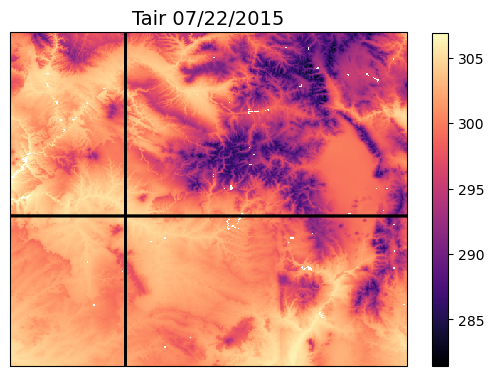

In [9]:
## Initialize the matplotlib figure
ax = plt.axes(projection=ccrs.PlateCarree())
fig = plt.gcf()

## establish the domain and add cartopy overlays
ax.set_extent([lon0, lonf, lat0, latf])
ax.add_feature(cfeature.BORDERS, linewidth=plot_spec.get("map_linewidth"), zorder=100)
ax.add_feature(cfeature.STATES, linewidth=plot_spec.get("map_linewidth"), zorder=100)
ax.coastlines()

## set the title from the configuration
ax.set_title(plot_spec.get("title"), fontsize=plot_spec.get("fontsize_title", 14))
ax.set_xlabel(plot_spec.get("xlabel"), fontsize=plot_spec.get("fontsize_labels", 12))
ax.set_ylabel(plot_spec.get("ylabel"), fontsize=plot_spec.get("fontsize_labels", 12))

## plot the data and create a color bar
pcmesh = ax.pcolormesh(
    subarr.lon[...],
    subarr.lat[...],
    subarr[...],
    cmap=plot_spec.get("cmap", "magma"),
    norm=plot_spec.get("norm", None),
    vmin=plot_spec.get("vmin", None),
    vmax=plot_spec.get("vmax", None),
    )

fig.colorbar(
    pcmesh,
    ax=ax,
    shrink=plot_spec.get("cbar_shrink", .9),
    label=plot_spec.get("cbar_label", None),
    orientation=plot_spec.get("cbar_orient", "vertical"),
    pad=plot_spec.get("cbar_pad", 0.05),
    norm=plot_spec.get("norm"),
    )